In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv('./cleaned_cyberbullying_tweets.csv')
df['sentiment_encoded'].value_counts()

sentiment_encoded
5    7888
0    7808
1    7697
2    7318
3    6315
Name: count, dtype: int64

In [3]:
df.head()

,text_clean,sentiment_encoded
0,word katandandre food crapilicious mkr,3
1,aussietv white mkr theblock imacelebrityau tod...,3
2,classy whore red velvet cupcake,3
3,meh thanks head concerned another angry dude t...,3
4,isi account pretending kurdish account like is...,3


Model Training

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import joblib

# Define the input and target variables
X = df['text_clean']
y = df['sentiment_encoded']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline that first vectorizes the text and then applies the Random Forest classifier
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Converts text to TF-IDF features
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))  # Random Forest classifier
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

joblib.dump(pipeline, 'random_forest.pkl')

['random_forest.pkl']

In [17]:
# Load the saved model from file
loaded_model = joblib.load('random_forest.pkl')

Classification Report

In [18]:
from sklearn.metrics import classification_report


# Assuming X_test and y_test are already defined in your environment:
y_pred = loaded_model.predict(X_test)

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1552
           1       0.99      0.99      0.99      1538
           2       0.94      0.88      0.91      1459
           3       0.81      0.90      0.85      1291
           5       0.97      0.96      0.96      1566

    accuracy                           0.94      7406
   macro avg       0.94      0.94      0.94      7406
weighted avg       0.94      0.94      0.94      7406



Confusion Matrix

Confusion Matrix:
[[1515    0    2   33    2]
 [   4 1519    4    8    3]
 [   0    3 1286  165    5]
 [  19    6   64 1158   44]
 [   1    1    7   57 1500]]


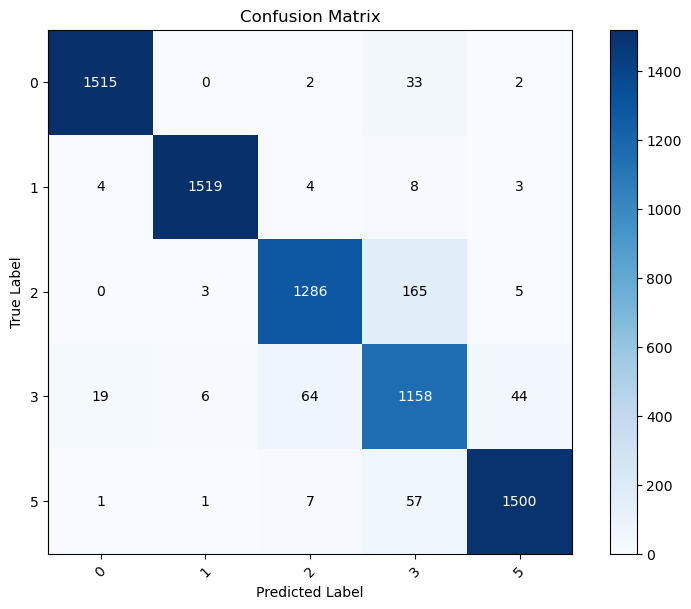

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate and print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Annotate each cell with its value
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Cross Validation Score

In [20]:
from sklearn.model_selection import cross_val_score

# If you have your full dataset (X and y) available, perform cross-validation
cv_scores = cross_val_score(loaded_model, X, y, cv=5)
print("Cross Validation Scores:")
print(cv_scores)
print("Mean Cross Validation Score:", cv_scores.mean())


Cross Validation Scores:
[0.94747502 0.93720459 0.93841999 0.93787981 0.93774477]
Mean Cross Validation Score: 0.9397448352459081
